<a href="https://colab.research.google.com/github/Iditc/log-anomaly-detection/blob/main/notebooks/07_xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Imports and paths
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

BASE = Path('/content/drive/MyDrive/log-anomaly-detection')
DATA_PROC = BASE / 'data' / 'processed'
RESULTS = BASE / 'results'

In [3]:
# Install XGBoost
!pip install xgboost -q

In [4]:
# Load features and split train/test
import xgboost as xgb

df = pd.read_parquet(DATA_PROC / "hdfs_features.parquet")
X = df.drop(columns=["Label"]).values
y = (df["Label"] == "Anomaly").astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,} | Anomaly rate: {y.mean():.2%}")

Train: 460,048 | Test: 115,013 | Anomaly rate: 2.93%


Train XGBoost. The scale_pos_weight parameter handles the class imbalance by giving more weight to the rare anomaly class

In [5]:
# Train XGBoost with class imbalance handling
print("Training XGBoost...")
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)
model.fit(X_train, y_train)
print("Training complete.")

Training XGBoost...
Training complete.


Evaluate on test set

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    111645
     Anomaly       0.99      1.00      0.99      3368

    accuracy                           1.00    115013
   macro avg       0.99      1.00      1.00    115013
weighted avg       1.00      1.00      1.00    115013

Total misclassifications: 44 out of 115,013
False Positives: 44
False Negatives: 0


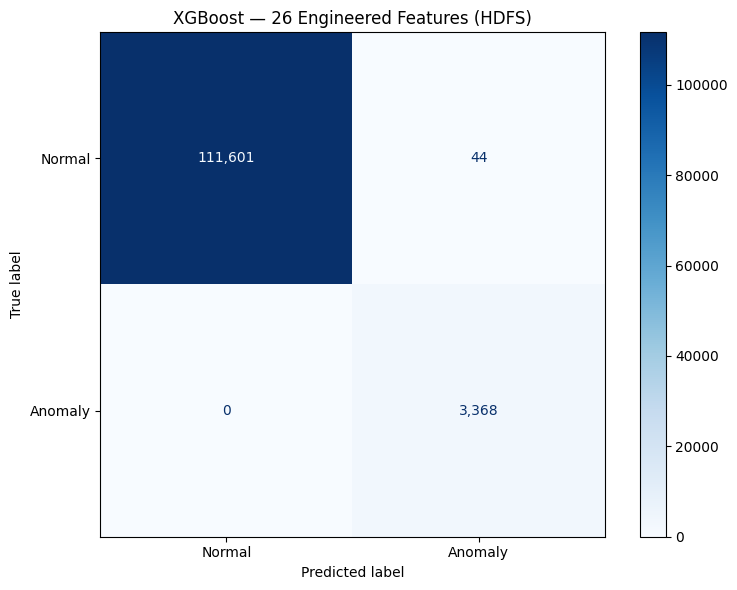

In [6]:
# Predict and evaluate on test set
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Normal", "Anomaly"]))

# Check actual errors
errors = (y_pred != y_test).sum()
print(f"Total misclassifications: {errors} out of {len(y_test):,}")
print(f"False Positives: {((y_pred == 1) & (y_test == 0)).sum()}")
print(f"False Negatives: {((y_pred == 0) & (y_test == 1)).sum()}")

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Anomaly"])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", values_format=",")
ax.set_title("XGBoost — 26 Engineered Features (HDFS)")
plt.tight_layout()
plt.savefig(str(RESULTS / "xgboost_confusion_matrix.png"), dpi=150)
plt.show()

XGBoost caught ALL anomalies (0 false negatives) — but at the cost of more false alarms (44 vs 15).

In cybersecurity this is often preferred — better to investigate 44 false alarms than miss 4 real attacks. The scale_pos_weight parameter pushed the model to never miss an anomaly

Let's also check feature importance to compare with Random Forest

In [7]:
# Feature importance comparison
feature_names = df.drop(columns=["Label"]).columns
feat_imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
print("Top 10 features:")
print(feat_imp.head(10).to_string())

Top 10 features:
t_4                   0.460700
unique_templates      0.255890
t_32                  0.067487
t_33                  0.064084
t_21                  0.059135
anomaly_only_count    0.024033
t_47                  0.020519
t_34                  0.017987
t_17                  0.011370
t_13                  0.007371


Random Forest relied most on t_32 (error template) and has_error_template.

XGBoost relies most on t_4 (46%) and unique_templates (26%) — the lifecycle completion features. It learned that missing t_4 is the strongest signal, which aligns with our analysis (t_4 appears in 100% of normal blocks, only 63% of anomaly).

Both models use our engineered features in the top 10 — confirms the feature engineering was valuable